In [1]:
import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

SEED = 1234

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from project.loader import Loader
from project.CROP.models.crop2 import Crop2 
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection


dataset = "fashion"
inter=256
lat=64

data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)
cvae = Loader.cvae(model_name="int_256_lat_64_beta_0_2_fashion.keras")
#cvae = Loader.cvae(model_name="int_256_lat_64_beta_0_01_fashion.keras")
x_train = data["x_train"]
x_train_1 = data["x_train_1"]
y_train = data["y_train"]
y_train_1 = data["y_train_1"]
ITERATIONS = 30

#c =Crop2(predictor=predictor,lat=lat,inter=inter,dataset=dataset)
#c = Crop3EstimationCorrection(predictor=predictor,lat=lat,inter=inter,dataset=dataset)
c = Crop3EstimationCorrection(predictor=predictor,cvae=cvae,dataset=dataset)

def objective(trial):
    #alpha_1 = trial.suggest_float("alpha_1", -50, 0)
    #alpha_2 = trial.suggest_float("alpha_2", -50, 0)
    #bias    = trial.suggest_float("bias", 0, 2)
    #slope   = trial.suggest_float("slope", 15, 25)
    gamma   = trial.suggest_float("gamma", 0, 2)
    delta   = trial.suggest_float("delta", 0, 2)
    n_images = 1000

    try:

        # Selección de datos
        X0 = x_train[:n_images]
        Y0 = y_train[:n_images]

        X1 = x_train_1[:n_images]
        Y1 = y_train_1[:n_images]

        # Randomización independiente para (x_train, y_train)
        idx0 = np.random.permutation(len(X0))
        X0 = X0[idx0]
        Y0 = Y0[idx0]

        # Randomización independiente para (x_train_1, y_train_1)
        idx1 = np.random.permutation(len(X1))
        X1 = X1[idx1]
        Y1 = Y1[idx1]

        metrics = c.unmix(
            X0,
            X1,
            Y0,
            Y1,
            params={'gamma':gamma,'delta':delta}, #crop 2
            #params={'gamma': 1.0602623807869416,'delta':delta}, #msnit ssim crop2 -->crop3
            #params={'gamma': 0.7267875665823903, 'delta': delta}, #  crop2--> crop3
            #params={'gamma': 0.9256608959277062,'delta':delta}, #ssim fashion crop2-->crop3
            #params={'alpha_1':alpha_1,'alpha_2':alpha_2,'gamma':1.6016 ,'delta': 0.422}, #solocrop3            
            iterations=ITERATIONS,
            show_metrics=False
        )

        return float(metrics["ssim"][0])

    except Exception as e:
        print(f"Error: {e}")
        return float("-inf")  
    



2026-07-01 09:54:35.829603: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 09:54:35.830163: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-01 09:54:35.838275: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-01 09:54:35.844245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782910475.855959   11370 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782910475.85

Usando fashion como dataset


2026-07-01 09:54:39.424261: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
import optuna

# Creamos un estudio de minimización
study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials=100) 

# Mostramos los mejores resultados
print("\n📊 Mejores hiperparámetros encontrados:")
print(study.best_trials)

/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-01 09:56:50,002] A new study created in memory with name: no-name-ea6df993-c1c4-4399-b47c-1551aca0059a
[I 2026-07-01 09:56:53,869] Trial 0 finished with value: 0.3828262388706207 and parameters: {'gamma': 0.13971705502478327, 'delta': 1.5024803555976263}. Best is trial 0 with value: 0.3828262388706207.
[I 2026-07-01 09:56:57,446] Trial 1 finished with value: 0.45081549882888794 and parameters: {'gamma': 0.6862520755913539, 'delta': 1.5674866258549627}. Best is trial 1 with value: 0.45081549882888794.
[I 2026-07-01 09:57:00,750] Trial 2 finished with value: 0.6915117502212524 and parameters: {'gamma': 1.1888134490753341, 'delta': 0.8626678874929385}. Best is trial 2 with value: 0.6915117502212524.
[I 2026-0


📊 Mejores hiperparámetros encontrados:
[FrozenTrial(number=82, state=1, values=[0.7172075510025024], datetime_start=datetime.datetime(2026, 7, 1, 10, 1, 21, 793267), datetime_complete=datetime.datetime(2026, 7, 1, 10, 1, 24, 963994), params={'gamma': 1.3818604713140525, 'delta': 0.62035665303693}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'gamma': FloatDistribution(high=2.0, log=False, low=0.0, step=None), 'delta': FloatDistribution(high=2.0, log=False, low=0.0, step=None)}, trial_id=82, value=None)]


In [15]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 19.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
#optuna.visualization.plot_slice(study, params=['gamma'])
#optuna.visualization.plot_slice(study, params=['delta'])
optuna.visualization.plot_slice(study, params=['gamma','delta'])

#optuna.visualization.plot_slice(study, params=['bias','slope'])
#optuna.visualization.plot_slice(study, params=['alpha_1','alpha_2'])



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                   14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,
                                   26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
                                   38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
                                   50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61,
                                   62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73,
                                   74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
                                   86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97,
                                   98, 99],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': True},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [1.5024803555976263, 1.5674866258549627, 0.8626678874929385,
                    0.8119042238142646, 1.1601400606901453, 1.2203493065978774,
                    1.405661390594123, 1.4828734294047834, 1.8325626561077895,
                    1.2737589758684775, 0.2225532754744024, 0.11460385294974508,
                    0.6061194573547792, 0.7555097262399127, 0.5287457194408703,
                    0.4600961533191577, 0.524490310787944, 0.48358433389391087,
                    0.3200755474677577, 0.6404710684559338, 1.8044683932405547e-05,
                    0.633311788524611, 0.6622243615540404, 1.000810017393567,
                    0.6560371556012091, 0.9694255780348551, 0.3346773681999952,
                    1.0240141088361863, 0.6617058189048587, 0.30256896064602556,
                    0.8721003925934355, 0.6753527468268888, 0.5896149516352185,
                    0.4494270459015115, 0.7885638772528808, 0.5787154547116032,
                    0.9026930850895603, 1.0931634935008854, 1.9597486804696338,
                    0.7488120223639658, 0.40575590984071186, 0.5976274818830449,
                    0.1722030011757505, 0.5724395748189398, 0.8466115772322408,
                    0.37016267401558933, 0.59005077076112, 0.7576051008092594,
                    1.3123048645330566, 1.7049513970255221, 0.26072381393182614,
                    0.6723848852903742, 0.5054897397518656, 0.6175015941447591,
                    0.6827678198511743, 0.9455595069903984, 0.4394422413131356,
                    0.7435561962416286, 0.5275669403751071, 0.525649866928783,
                    0.14948191638466934, 0.8240888803794495, 0.38707657055893996,
                    0.6030602942475838, 0.5292321422223032, 0.503765171127786,
                    0.24208318031647513, 0.46736537479475715, 0.7245549777890327,
                    0.3570649023137423, 0.03952460979254613, 0.45215913713443867,
                    0.5467096909841187, 0.306672621493631, 0.48012216242264943,
                    0.4129721054028718, 0.6303762821294603, 0.79911886048876,
                    0.7098139293436799, 0.567371122994724, 0.5694187166501073,
                    0.568616198397729, 0.62035665303693, 0.6135248549864843,
                    0.6294273471410147, 0.6423010532133344, 0.9069509390780671,
                    0.7084862118939611, 0.50946162364163

# Validación


Usando fashion como dataset
Run 1/2


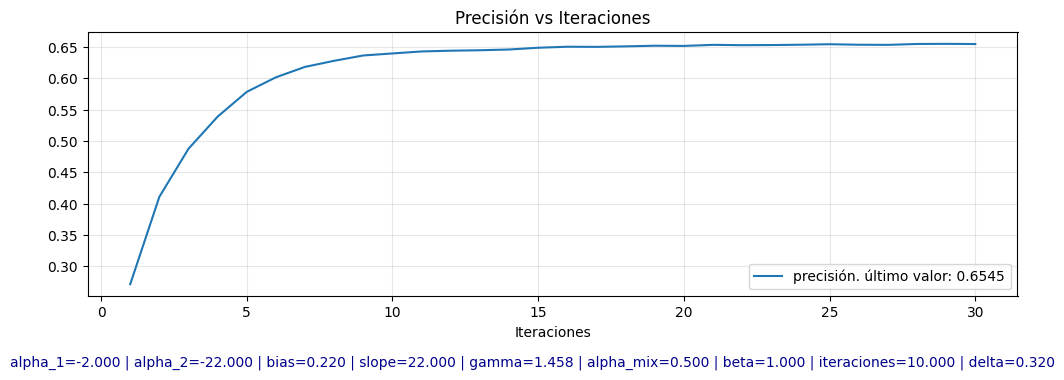

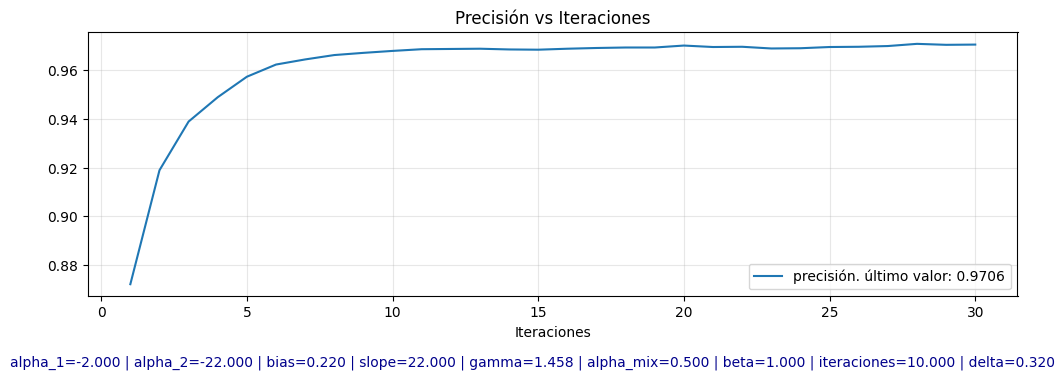

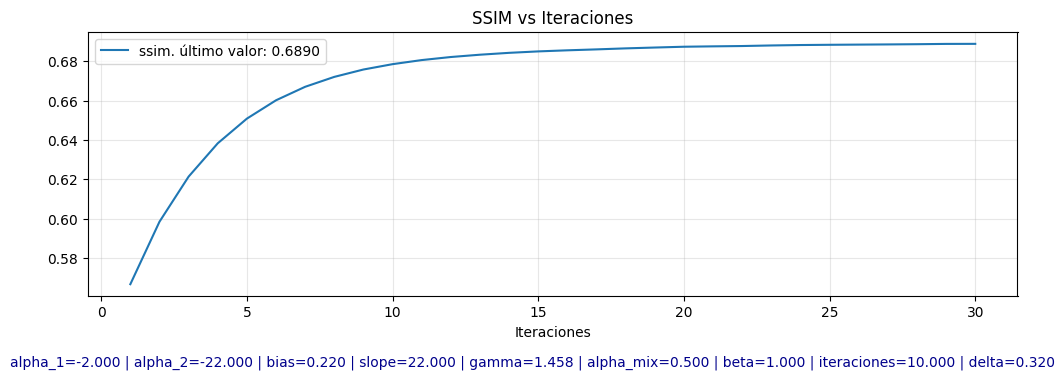

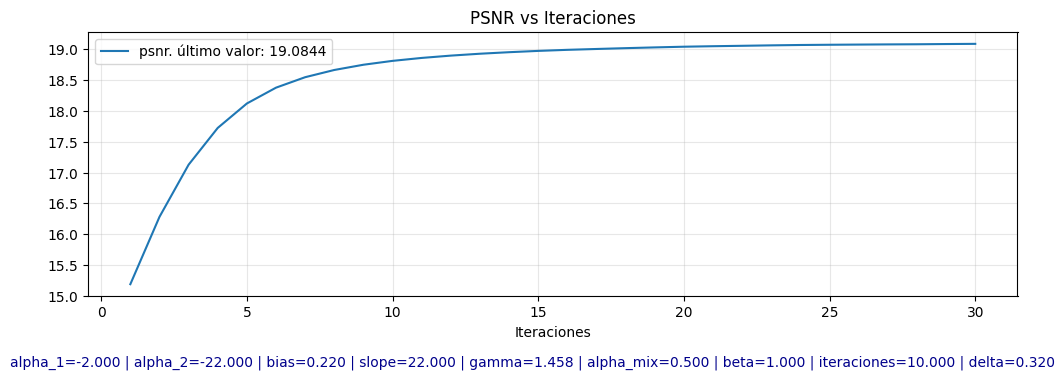


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.458
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.320

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.084  std:3.246
mask_bpsnr       : mean: 11.441  std:1.656
ssim             : mean: 0.689  std:0.118
acc_at_least_one : 0.971
acc_both         : 0.654



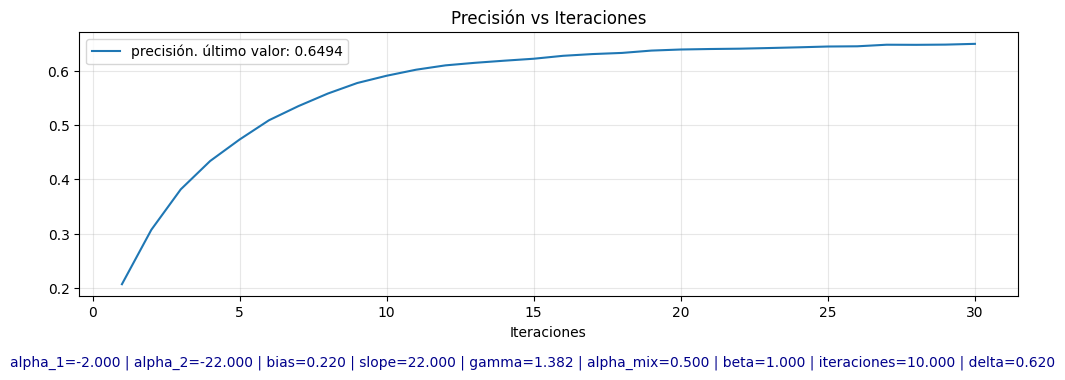

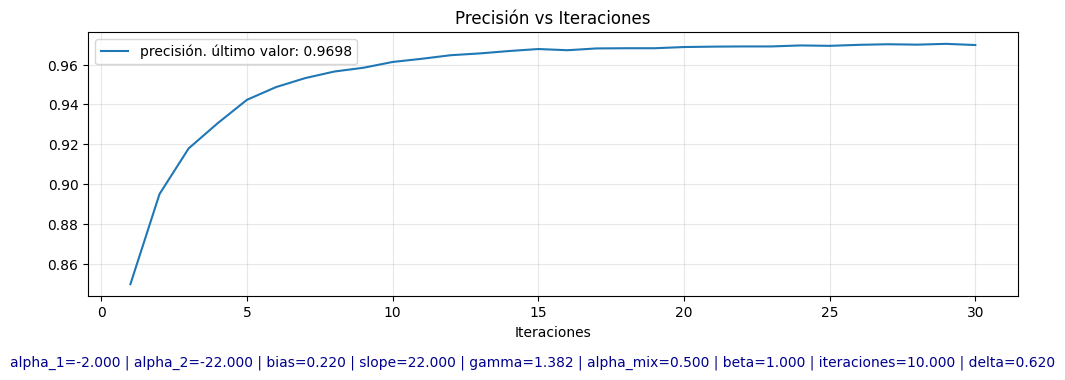

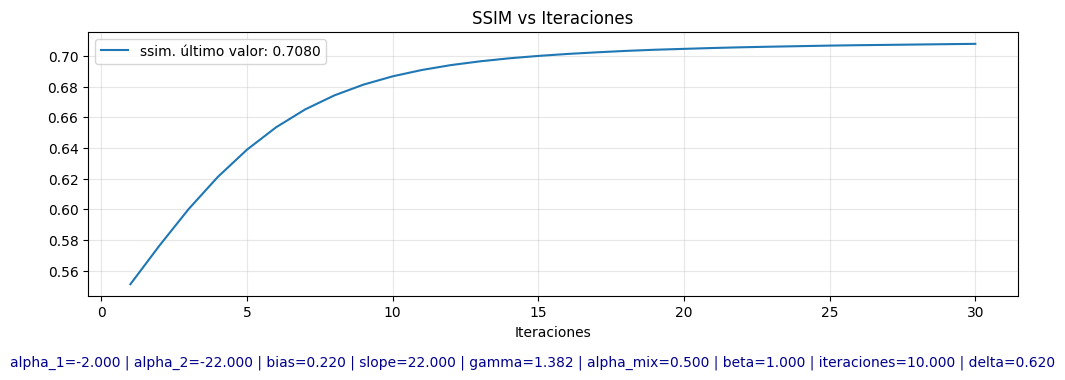

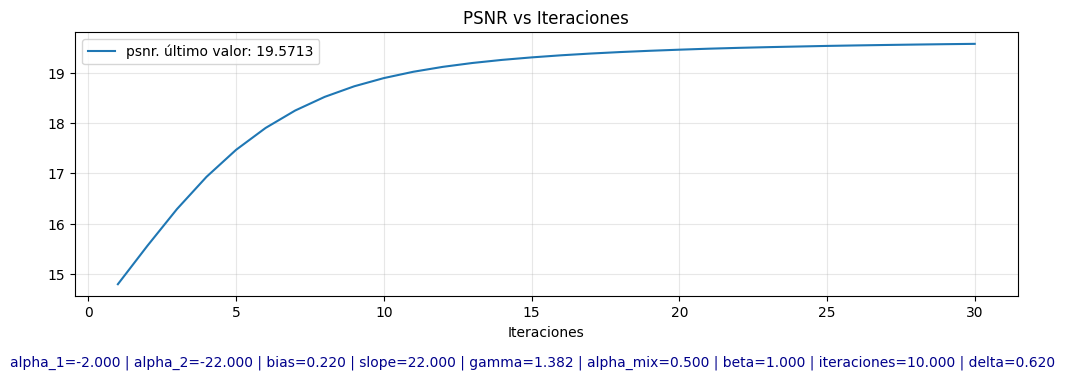


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.382
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.620

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.571  std:3.756
mask_bpsnr       : mean: 11.851  std:1.892
ssim             : mean: 0.708  std:0.119
acc_at_least_one : 0.970
acc_both         : 0.649

Run 2/2


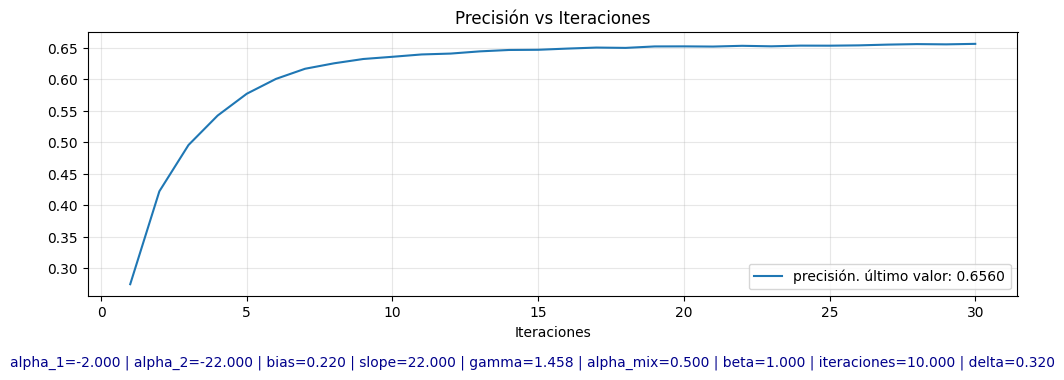

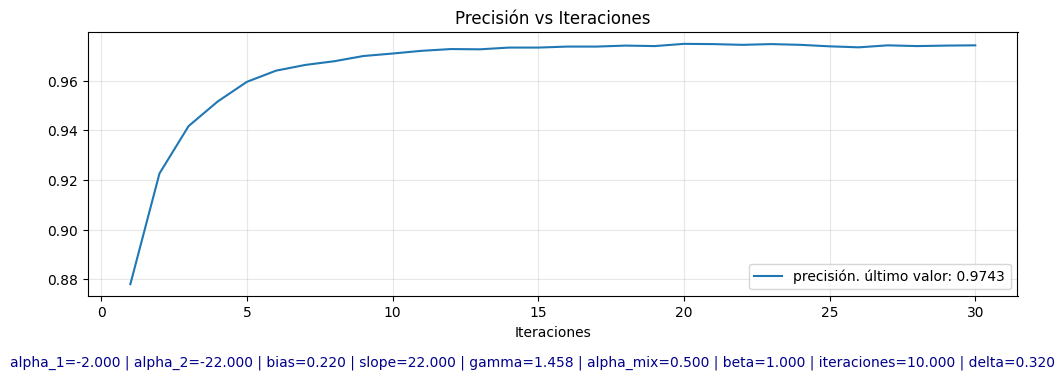

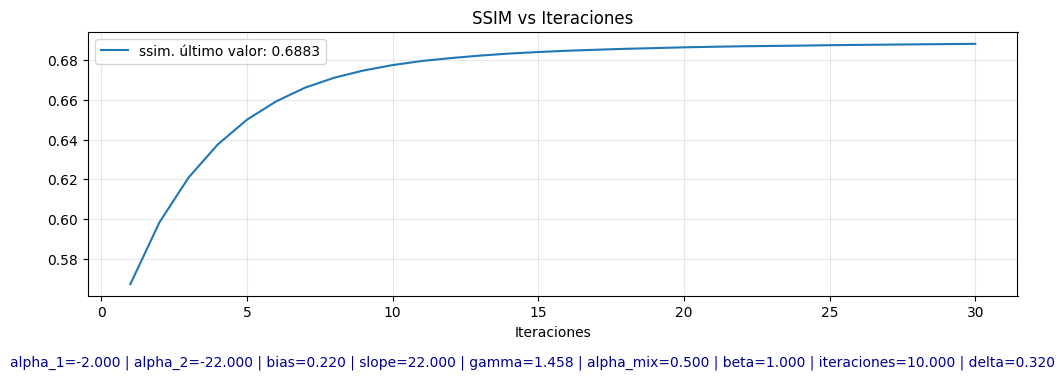

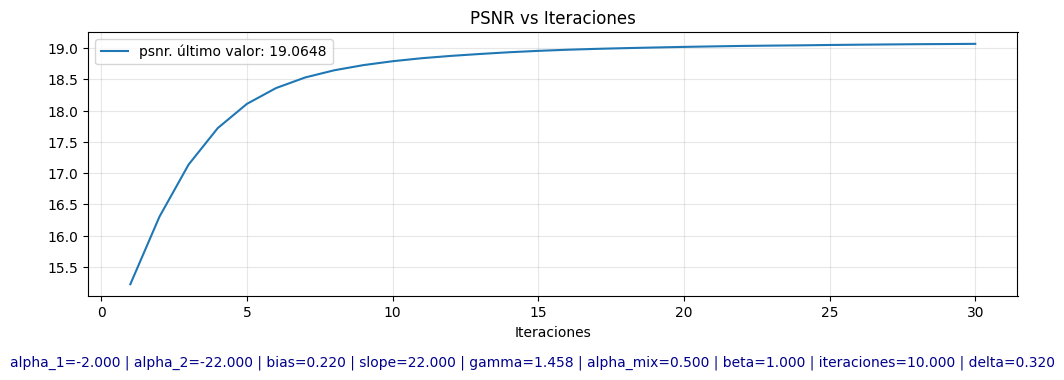


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.458
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.320

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.065  std:3.244
mask_bpsnr       : mean: 11.454  std:1.677
ssim             : mean: 0.688  std:0.119
acc_at_least_one : 0.974
acc_both         : 0.656



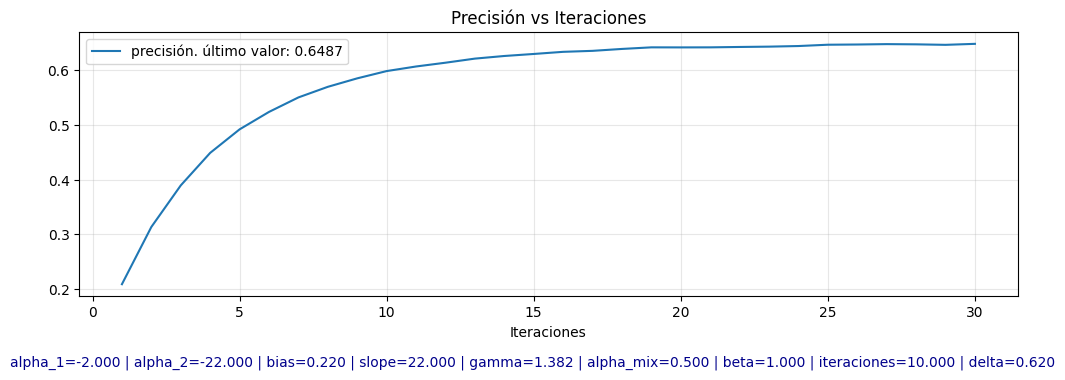

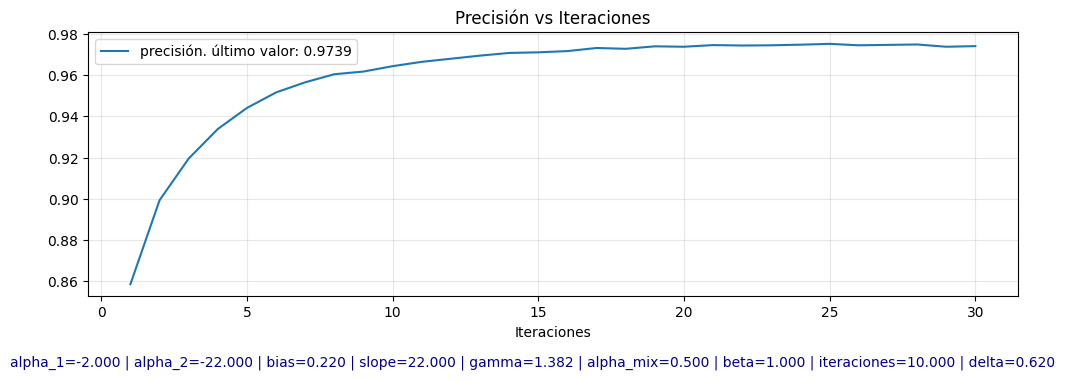

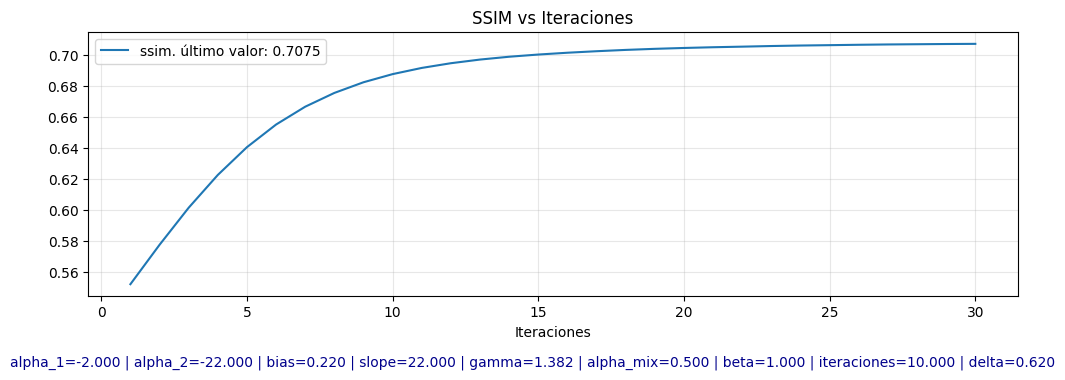

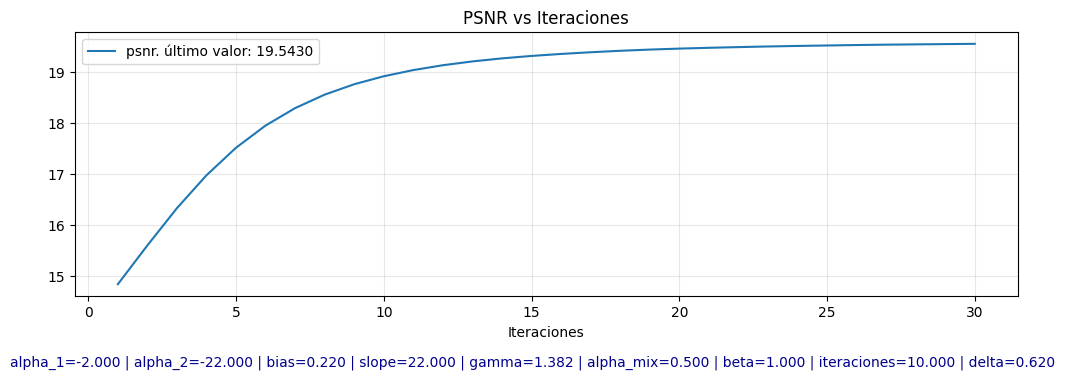


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.382
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.620

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.543  std:3.720
mask_bpsnr       : mean: 11.859  std:1.900
ssim             : mean: 0.707  std:0.118
acc_at_least_one : 0.974
acc_both         : 0.649



In [4]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
from project.CROP.models.crop2 import Crop2
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection
from project.CROP.models.crop3_mask_correction import Crop3MaskCorrection
from project.CROP.models.crop3_all_corrections import Crop3AllCorrections
from project.CROP.models.crop3_one_hot import Crop3OH
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random



DATASET = "fashion" # mnist o fashion
LAT = 64
INTER = 256


cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
beta_cvae = Loader.cvae(model_name="int_256_lat_64_beta_0_2_fashion.keras")
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

N_RUNS = 2

ITERATIONS = 30
N_PICTURES = -1


results_crop2 = {
    "acc": [],
    "ssim": [],
    "psnr": []
}

results_crop3 = {
    "acc": [],
    "ssim": [],
    "psnr": []
}


x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]

for run in range(N_RUNS):

    print(f"Run {run+1}/{N_RUNS}")

    # --------------------------
    # Randomización grupo 1
    # --------------------------
    idx0 = np.random.permutation(len(x_test))

    X0 = x_test[idx0][:N_PICTURES]
    Y0 = y_test[idx0][:N_PICTURES]

    # --------------------------
    # Randomización grupo 2
    # --------------------------
    idx1 = np.random.permutation(len(x_test_1))

    X1 = x_test_1[idx1][:N_PICTURES]
    Y1 = y_test_1[idx1][:N_PICTURES]

    # ==================================================
    # Crop2
    # ==================================================
    c2 = Crop3EstimationCorrection(
        cvae=cvae,
        predictor=predictor
    )

    metrics2 = c2.unmix(
        X0,
        X1,
        Y0,
        Y1,
        iterations=ITERATIONS,
        show_image=False,
        labels=labels,
        #params={'gamma': 0.7267875665823903}, #fashion acc
        #params={'gamma': 1.3737512979787159}, #fashion ssim crop2 -> crop3
        #params={'gamma': 0.9256608959277062},# mnist acc
        #params={'gamma': 1.0602623807869416,'delta': 0.09236729663810188},# mnist ssim crop2-->crop3
        #params={'gamma': 1.3204856734008088, 'delta': 0.2935340068626094},# para cvae con beta= 0.4 acc
        #params={'gamma': 1.6016, 'delta': 0.422},#best ssim fashion
        params= {'gamma':1.458,'delta':0.3202}, # best acc fashion crop3  
        show_all_curves=True
    )

    results_crop2["acc"].append(metrics2["acc_both_plot"])
    results_crop2["ssim"].append(metrics2["ssim_plot"])
    results_crop2["psnr"].append(metrics2["psnr_plot"])

    # ==================================================
    # Crop3 Estimation Correction
    # ==================================================
    
    c3 = Crop3EstimationCorrection(
        cvae=beta_cvae,
        predictor=predictor
    )

    metrics3 = c3.unmix(
        X0,
        X1,
        Y0,
        Y1,
        iterations=ITERATIONS,
        show_image=False,
        labels=labels,
        #params={'gamma': 1.4943626079280168, 'delta': 0.6422972479927117},#beta 0.3 ssim fashion
        #params={'gamma': 0.5274108715737021, 'delta': 0.45713981282943117},# beta 0.3 acc fashion
        #params={'gamma': 1.6016, 'delta': 0.422},#best ssim fashion
        params={'gamma': 1.3818604713140525, 'delta': 0.62035665303693}, # crop3 beta=0.2 ssim fashion 
        #params={'gamma': 1.3204856734008088, 'delta': 0.2935340068626094},# para cvae con beta= 0.4 acc
        #params={'gamma': 1.4471168201657352, 'delta': 0.2996902649135979}, #para el cvae con beta =0.4 (ssim)
        #params={'gamma': 1.0507384749934656, 'delta': 0.03166310123273044},
        #params={'gamma': 1.0602623807869416,'delta': 0.09236729663810188},# mnist ssim crop2-->crop3
        #params={'gamma': 0.5694478265784159, 'delta': 0.36324698723773097},#mnist acc--> optim conjunta
        #params={'gamma': 0.9256608959277062,'delta': 0.19085600935287622},# minst acc
        #params={'gamma': 1.458049947932175, 'delta': 0.32022170962467505}, # 
        #params={'gamma': 1.6016284578229278, 'delta': 0.42202817752402877},
        #params={'gamma': 1.3737512979787159,'delta': 0.3537826782379939},# fashion ssim crop2-->crop3
        show_all_curves=True
    )

    results_crop3["acc"].append(metrics3["acc_both_plot"])
    results_crop3["ssim"].append(metrics3["ssim_plot"])
    results_crop3["psnr"].append(metrics3["psnr_plot"])


# ======================================================
# Conversión a arrays
# ======================================================

for results in [results_crop2, results_crop3]:

    results["acc"] = np.asarray(results["acc"])
    results["ssim"] = np.asarray(results["ssim"])
    results["psnr"] = np.asarray(results["psnr"])

    results["mean_acc"] = results["acc"].mean(axis=0)
    results["std_acc"] = results["acc"].std(axis=0)

    results["mean_ssim"] = results["ssim"].mean(axis=0)
    results["std_ssim"] = results["ssim"].std(axis=0)

    results["mean_psnr"] = results["psnr"].mean(axis=0)
    results["std_psnr"] = results["psnr"].std(axis=0)




In [20]:
#results_crop2['std_acc']
results_crop3['std_psnr']



array([0.01696986, 0.01529538, 0.01182451, 0.00930535, 0.00947815,
       0.01140369, 0.01255371, 0.01287251, 0.01284821, 0.01232666,
       0.01142704, 0.01180414, 0.01230034, 0.01257783, 0.01295758,
       0.01322426, 0.01335239, 0.01343712, 0.01382674, 0.01373266,
       0.01364988, 0.01366495, 0.01376763, 0.01404624, 0.01415507,
       0.01450522, 0.01430674, 0.01411839, 0.01441518, 0.01451125],
      dtype=float32)

# SSIM crop3 beta=0.4

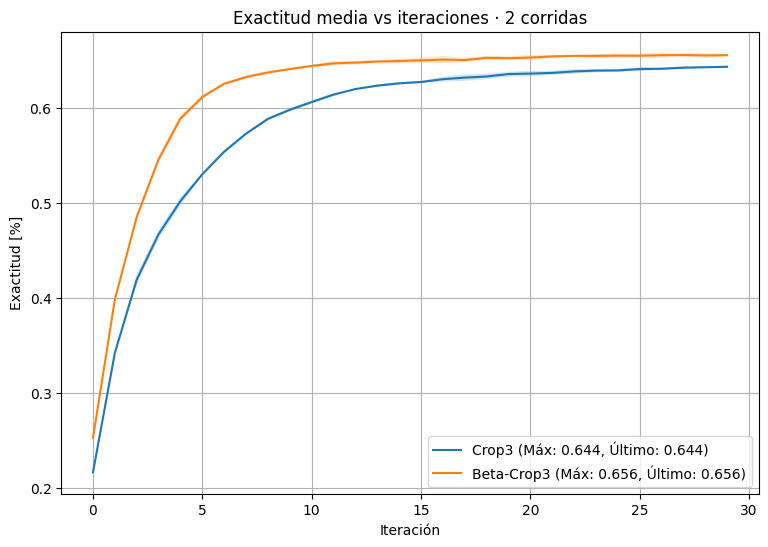

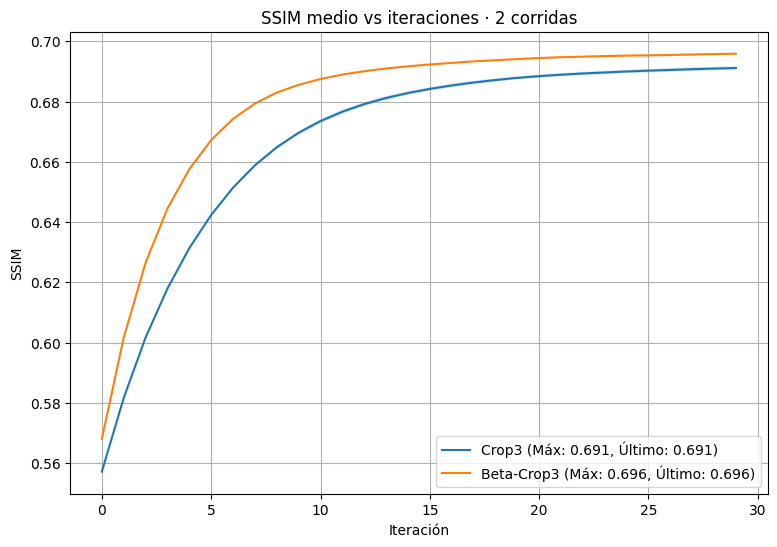

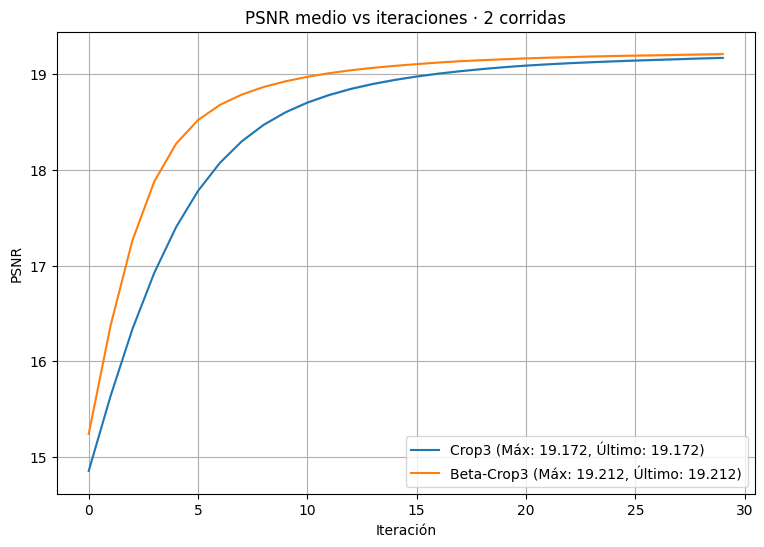

In [6]:
plt.figure(figsize=(9, 6))

for name, results in {
    #"Crop2": results_crop2,
    "Crop3": results_crop2,
    "Beta-Crop3": results_crop3
}.items():

    acc = results["mean_acc"]
    std = results["std_acc"]

    x = np.arange(len(acc))

    plt.plot(
        x,
        acc,
        label=f"{name} (Máx: {acc.max():.3f}, Último: {acc[-1]:.3f})"
    )

    plt.fill_between(
        x,
        acc - std,
        acc + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"Exactitud media vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("Exactitud [%]")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop3": results_crop2,
    "Beta-Crop3": results_crop3
}.items():

    ssim = results["mean_ssim"]
    std = results["std_ssim"]

    x = np.arange(len(ssim))

    plt.plot(
        x,
        ssim,
        label=f"{name} (Máx: {ssim.max():.3f}, Último: {ssim[-1]:.3f})"
    )

    plt.fill_between(
        x,
        ssim - std,
        ssim + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"SSIM medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("SSIM")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop3": results_crop2,
    "Beta-Crop3": results_crop3
}.items():

    psnr = results["mean_psnr"]
    std = results["std_psnr"]

    x = np.arange(len(psnr))

    plt.plot(
        x,
        psnr,
        label=f"{name} (Máx: {psnr.max():.3f}, Último: {psnr[-1]:.3f})"
    )

    plt.fill_between(
        x,
        psnr - std,
        psnr + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"PSNR medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("PSNR")
plt.legend()
plt.show()

# Exactitud crop3 beta=0.4

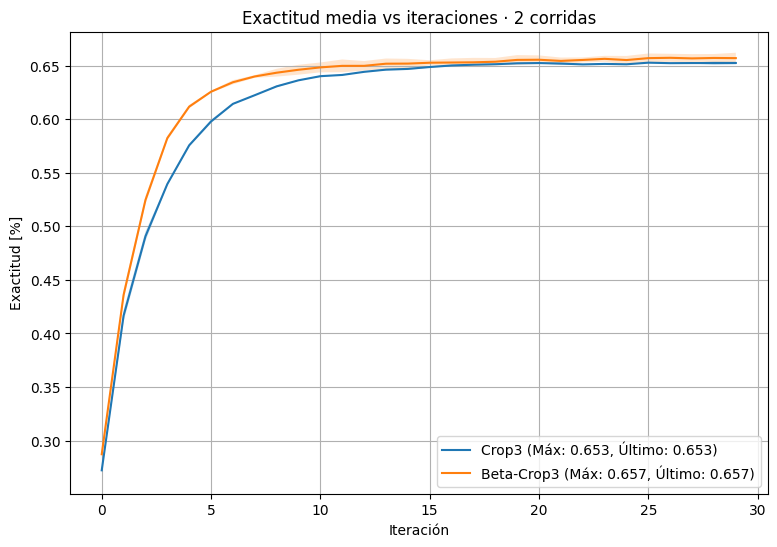

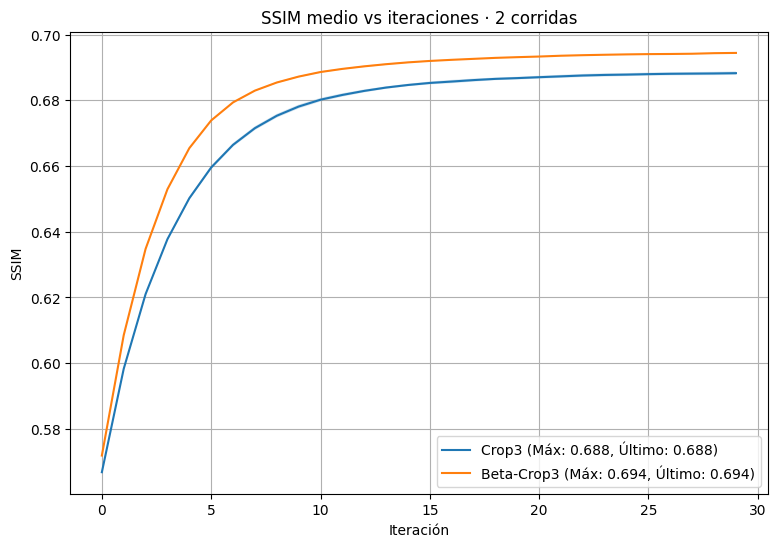

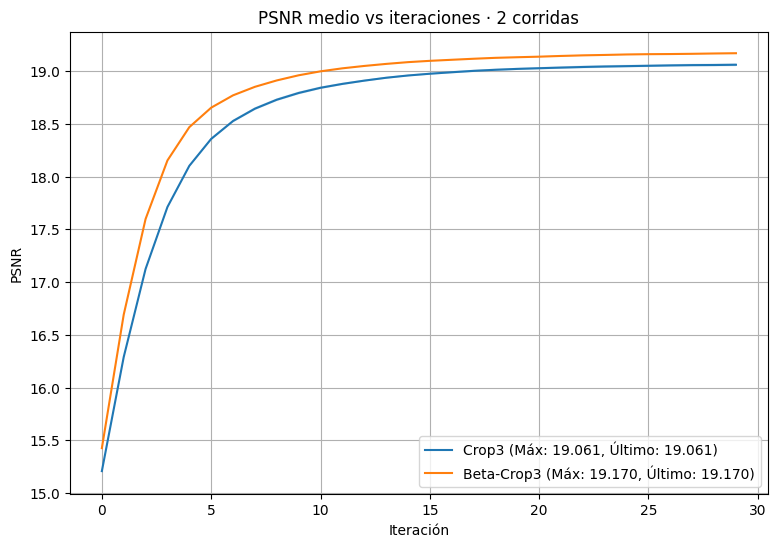

In [8]:
plt.figure(figsize=(9, 6))

for name, results in {
    #"Crop2": results_crop2,
    "Crop3": results_crop2,
    "Beta-Crop3": results_crop3
}.items():

    acc = results["mean_acc"]
    std = results["std_acc"]

    x = np.arange(len(acc))

    plt.plot(
        x,
        acc,
        label=f"{name} (Máx: {acc.max():.3f}, Último: {acc[-1]:.3f})"
    )

    plt.fill_between(
        x,
        acc - std,
        acc + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"Exactitud media vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("Exactitud [%]")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop3": results_crop2,
    "Beta-Crop3": results_crop3
}.items():

    ssim = results["mean_ssim"]
    std = results["std_ssim"]

    x = np.arange(len(ssim))

    plt.plot(
        x,
        ssim,
        label=f"{name} (Máx: {ssim.max():.3f}, Último: {ssim[-1]:.3f})"
    )

    plt.fill_between(
        x,
        ssim - std,
        ssim + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"SSIM medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("SSIM")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop3": results_crop2,
    "Beta-Crop3": results_crop3
}.items():

    psnr = results["mean_psnr"]
    std = results["std_psnr"]

    x = np.arange(len(psnr))

    plt.plot(
        x,
        psnr,
        label=f"{name} (Máx: {psnr.max():.3f}, Último: {psnr[-1]:.3f})"
    )

    plt.fill_between(
        x,
        psnr - std,
        psnr + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"PSNR medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("PSNR")
plt.legend()
plt.show()

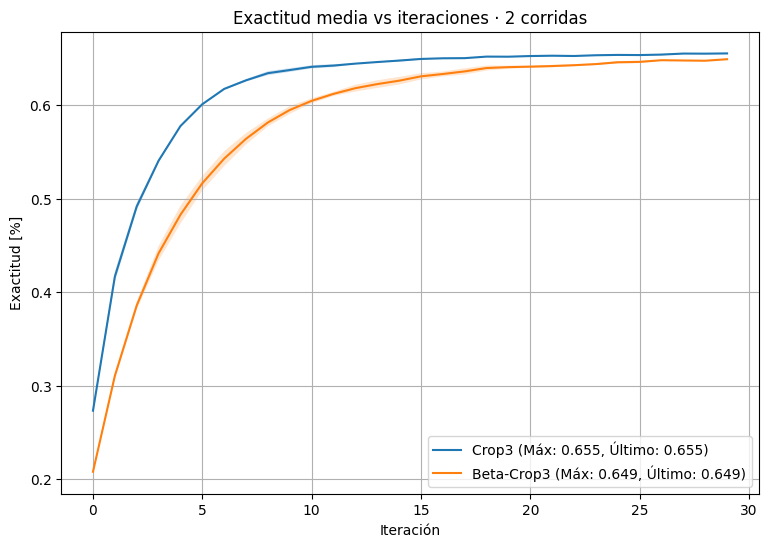

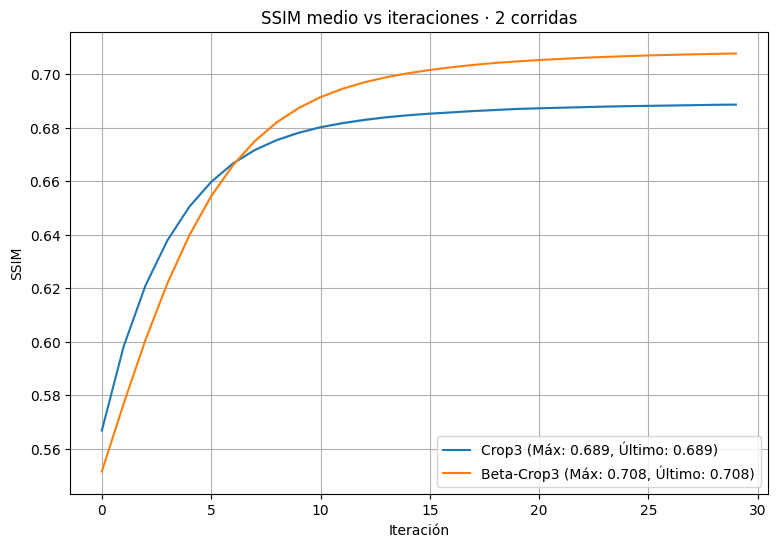

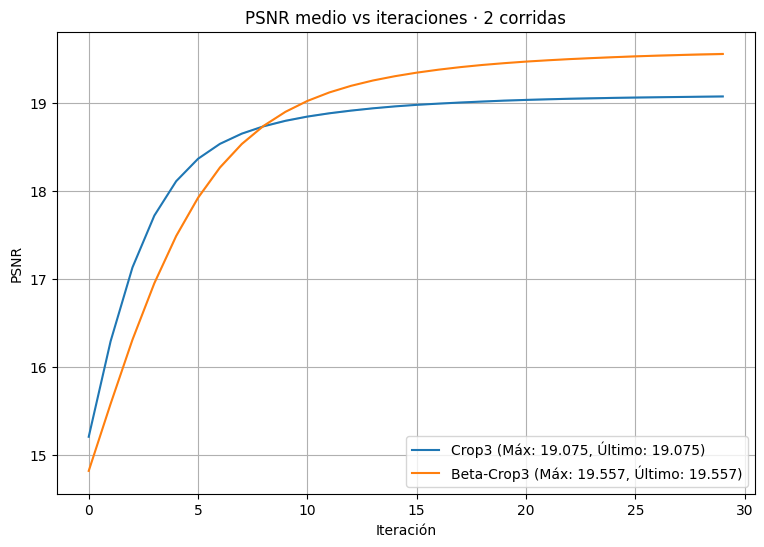

In [5]:
plt.figure(figsize=(9, 6))

for name, results in {
    #"Crop2": results_crop2,
    "Crop3": results_crop2,
    "Beta-Crop3": results_crop3
}.items():

    acc = results["mean_acc"]
    std = results["std_acc"]

    x = np.arange(len(acc))

    plt.plot(
        x,
        acc,
        label=f"{name} (Máx: {acc.max():.3f}, Último: {acc[-1]:.3f})"
    )

    plt.fill_between(
        x,
        acc - std,
        acc + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"Exactitud media vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("Exactitud [%]")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop3": results_crop2,
    "Beta-Crop3": results_crop3
}.items():

    ssim = results["mean_ssim"]
    std = results["std_ssim"]

    x = np.arange(len(ssim))

    plt.plot(
        x,
        ssim,
        label=f"{name} (Máx: {ssim.max():.3f}, Último: {ssim[-1]:.3f})"
    )

    plt.fill_between(
        x,
        ssim - std,
        ssim + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"SSIM medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("SSIM")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop3": results_crop2,
    "Beta-Crop3": results_crop3
}.items():

    psnr = results["mean_psnr"]
    std = results["std_psnr"]

    x = np.arange(len(psnr))

    plt.plot(
        x,
        psnr,
        label=f"{name} (Máx: {psnr.max():.3f}, Último: {psnr[-1]:.3f})"
    )

    plt.fill_between(
        x,
        psnr - std,
        psnr + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"PSNR medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("PSNR")
plt.legend()
plt.show()